# 🏆 Segmentation 모델 평가 프레임워크

## 폴더 구조
```
eval_dataset/
├── image_001/
│   ├── image_001.jpg
│   └── gt_masks/
│       ├── laptop.png   ← 흰색=객체, 검정=배경
│       └── mouse.png
├── image_002/ ...
```

## 새 모델 추가 방법
**STEP 1 셀**에서 함수 하나만 추가하고 `MODELS`에 등록하세요.
```python
def my_model(img_path, W, H):
    return [
        {'label': 'laptop', 'confidence': 0.92, 'mask': np.ndarray(bool, shape H×W)},
    ]

MODELS = {
    'YOLO11x': model_yolo,
    'MyModel': my_model,
}
```

MODELS 내부에 이름과 정보를 넣어주어야 함 ('이름' : 정보)

정보에는 label, confidence, mask가 필요함.

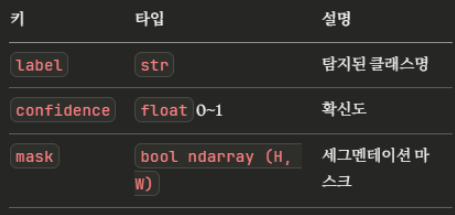

In [1]:
!pip install "ultralytics>=8.3.0" opencv-python-headless matplotlib numpy koreanize-matplotlib -q

In [2]:
import sys
import warnings
import datetime
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from ultralytics import YOLO

warnings.filterwarnings('ignore')

try:
    from koreanize_matplotlib import koreanize
    koreanize()
except ImportError:
    pass

print(f'Python: {sys.version}')


Python: 3.10.19 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 16:41:31) [MSC v.1929 64 bit (AMD64)]


---
## ✏️ INPUT — 설정


In [3]:
# ✏️ 여기만 수정
EVAL_DATASET_DIR = 'eval_dataset'
OUTPUT_DIR       = 'results'   # None → 날짜시간 자동 생성

# 출력 폴더 생성
if OUTPUT_DIR is None:
    OUTPUT_DIR = 'results_' + datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
OUT = Path(OUTPUT_DIR)
OUT.mkdir(exist_ok=True)

# 데이터셋 스캔
root = Path(EVAL_DATASET_DIR)
if not root.exists():
    raise FileNotFoundError(f"'{EVAL_DATASET_DIR}' 폴더가 없습니다.")

data_dirs = sorted(d for d in root.iterdir() if d.is_dir())
if not data_dirs:
    raise ValueError(f"'{EVAL_DATASET_DIR}' 안에 하위 폴더가 없습니다.")

print(f'📁 출력 폴더 : {OUT.resolve()}')
print(f'📂 데이터 수 : {len(data_dirs)}개')
for d in data_dirs:
    imgs  = list(d.glob('*.jpg')) + list(d.glob('*.png'))
    masks = list((d / 'gt_masks').glob('*.png')) if (d / 'gt_masks').exists() else []
    print(f'   📁 {d.name:30} | 이미지:{len(imgs)}  GT마스크:{len(masks)}')


📁 출력 폴더 : C:\Users\Administrator\Documents\Machine Vision\results
📂 데이터 수 : 6개
   📁 img1                           | 이미지:1  GT마스크:5
   📁 img2                           | 이미지:1  GT마스크:7
   📁 img3                           | 이미지:1  GT마스크:7
   📁 img4                           | 이미지:1  GT마스크:7
   📁 img5                           | 이미지:1  GT마스크:5
   📁 img6                           | 이미지:1  GT마스크:4


---
## ✏️ STEP 1 — 모델 등록

- 각 모델을 함수로 정의 후 `MODELS` 딕셔너리에 등록
- **YOLO는 기본 제공** — 다른 모델은 아래 템플릿을 복사해서 추가
- 반환 형태: `[{'label': str, 'confidence': float, 'mask': bool ndarray(H,W)}, ...]`


In [4]:
# ─────────────────────────────────────────────────────────
# 공통 YOLO 추론 헬퍼 — 코드 중복 제거
# ─────────────────────────────────────────────────────────
def _run_yolo(yolo_model, img_path, W, H,
              conf=0.15, iou=0.40, imgsz=1280):
    """YOLO 모델 추론 → 공통 반환 형태 리스트"""
    res        = yolo_model(img_path, conf=conf, iou=iou, imgsz=imgsz,
                            retina_masks=True, verbose=False)[0]
    masks_data = res.masks.data.cpu().numpy() if res.masks is not None else None
    out = []
    for i, box in enumerate(res.boxes):
        mask = None
        if masks_data is not None:
            m    = cv2.resize(masks_data[i], (W, H), interpolation=cv2.INTER_LINEAR)
            mask = m > 0.5
        out.append({
            'label'     : yolo_model.names[int(box.cls[0].item())],
            'confidence': float(box.conf[0].item()),
            'mask'      : mask,
        })
    return out


# ─────────────────────────────────────────────────────────
# 모델 A — YOLO11x-seg (기본 제공)
# ─────────────────────────────────────────────────────────
_yolo_x = YOLO('yolo11x-seg.pt')

def model_yolo(img_path, W, H):
    return _run_yolo(_yolo_x, img_path, W, H)


# ─────────────────────────────────────────────────────────
# 모델 B — YOLO11n-seg
# ─────────────────────────────────────────────────────────
_yolo_n = YOLO('yolo11n-seg.pt')

def model_yolo1(img_path, W, H):
    return _run_yolo(_yolo_n, img_path, W, H)


# ─────────────────────────────────────────────────────────
# ✏️ 평가할 모델 등록 (이름: 함수)
# ─────────────────────────────────────────────────────────
MODELS = {
    'YOLO11x-seg': model_yolo,
    'YOLO11n-seg': model_yolo1,
}

print(f'✅ 등록된 모델: {list(MODELS.keys())}')


✅ 등록된 모델: ['YOLO11x-seg', 'YOLO11n-seg']


---
## STEP 2 — 배치 평가 실행

등록된 모든 모델을 동일한 dataset으로 자동 평가합니다.  
**이 셀은 수정할 필요 없습니다.**


In [5]:
# ── 평가 유틸 함수 ──────────────────────────────────────────
def compute_iou(a: np.ndarray, b: np.ndarray) -> float:
    i = np.logical_and(a, b).sum()
    u = np.logical_or(a, b).sum()
    return float(i / u) if u > 0 else 0.0


def compute_precision_recall(gt_mask, pred_mask):
    intersection = np.logical_and(gt_mask, pred_mask).sum()
    precision = float(intersection / pred_mask.sum()) if pred_mask.sum() > 0 else 0.0
    recall    = float(intersection / gt_mask.sum())   if gt_mask.sum()  > 0 else 0.0
    return precision, recall


def load_gt_masks(gt_dir: Path, W: int, H: int) -> list:
    """GT 마스크 PNG 파일들을 읽어 리스트로 반환"""
    result = []
    for f in sorted(gt_dir.glob('*.png')):
        parts = f.stem.rsplit('_', 1)
        label = (parts[0] if len(parts) == 2 and parts[1].isdigit() else f.stem).replace('_', ' ')
        raw   = cv2.imread(str(f), cv2.IMREAD_GRAYSCALE)
        if raw is None:
            print(f'  ⚠️  마스크 로드 실패: {f}')
            continue
        resized = cv2.resize(raw, (W, H), interpolation=cv2.INTER_NEAREST)
        result.append({'label': label, 'mask': resized > 127})
    return result


def match_and_score(gt_masks: list, detections: list) -> list:
    """GT 마스크와 탐지 결과를 매칭하여 평가 결과 반환"""
    # 인덱스 부여 (원본 리스트 보호)
    detections = [{**d, '_idx': i} for i, d in enumerate(detections)]
    used    = set()
    results = []

    for gt in gt_masks:
        gt_label, gt_mask = gt['label'], gt['mask']
        best_iou, best_det = -1.0, None

        # 1순위: 같은 레이블 중 IoU 최대
        for d in detections:
            if d['_idx'] in used or d['label'] != gt_label or d['mask'] is None:
                continue
            iou = compute_iou(gt_mask, d['mask'])
            if iou > best_iou:
                best_iou, best_det = iou, d

        # 2순위: 마스크 겹침 기준 fallback
        if best_det is None:
            for d in detections:
                if d['_idx'] in used or d['mask'] is None:
                    continue
                iou = compute_iou(gt_mask, d['mask'])
                if iou > best_iou:
                    best_iou, best_det = iou, d
            if best_det is not None and best_iou <= 0.0:
                best_det = None

        if best_det is not None:
            used.add(best_det['_idx'])
            precision, recall = compute_precision_recall(gt_mask, best_det['mask'])
            results.append({
                'gt_label'  : gt_label,
                'pred_label': best_det['label'],
                'confidence': best_det['confidence'],
                'iou'       : best_iou,
                'precision' : precision,
                'recall'    : recall,
                'score'     : best_iou * best_det['confidence'],
                'matched'   : True,
            })
        else:
            results.append({
                'gt_label'  : gt_label,
                'pred_label': None,
                'confidence': 0.0,
                'iou'       : 0.0,
                'precision' : 0.0,
                'recall'    : 0.0,
                'score'     : 0.0,
                'matched'   : False,
            })
    return results


def _get_image_file(data_dir: Path):
    """폴더에서 이미지 파일 하나를 찾아 반환 (없으면 None)"""
    imgs = ([f for f in data_dir.glob('*.jpg')] +
            [f for f in data_dir.glob('*.png') if 'gt_masks' not in str(f)])
    return imgs[0] if imgs else None


# ── 모델별 전체 배치 평가 ────────────────────────────────────────────────────
ALL_RESULTS = {}  # { 'ModelName': [이미지별 결과, ...] }

for model_name, model_fn in MODELS.items():
    print(f'\n{"="*65}')
    print(f'  🤖 {model_name} 평가 중...')
    print(f'{"="*65}')
    img_results = []

    for data_dir in data_dirs:
        gt_mask_dir = data_dir / 'gt_masks'
        img_path    = _get_image_file(data_dir)
        if img_path is None or not gt_mask_dir.exists():
            continue

        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            print(f'  ⚠️  이미지 로드 실패: {img_path}')
            continue
        H, W = img_bgr.shape[:2]

        detections = model_fn(str(img_path), W, H)
        gt_masks   = load_gt_masks(gt_mask_dir, W, H)
        eval_rs    = match_and_score(gt_masks, detections)

        img_score = float(np.mean([r['score'] for r in eval_rs])) if eval_rs else 0.0
        correct   = sum(1 for r in eval_rs if r['gt_label'] == r['pred_label'])

        img_results.append({
            'name'        : data_dir.name,
            'eval_results': eval_rs,
            'img_score'   : img_score,
            'correct'     : correct,
            'total'       : len(eval_rs),
        })

        print(f'  📁 {data_dir.name}')
        for r in eval_rs:
            pred = r['pred_label'] or '미탐지'
            mark = '⭕' if r['gt_label'] == r['pred_label'] else '❌'
            print(f'     {mark} {r["gt_label"]:20} → {pred:20} | IoU:{r["iou"]:.3f}  score:{r["score"]:.3f}')
        print(f'     정답 {correct}/{len(eval_rs)}  img_score:{img_score:.4f}\n')

    ALL_RESULTS[model_name] = img_results

print('✅ 전체 평가 완료')



  🤖 YOLO11x-seg 평가 중...
  📁 img1
     ⭕ book                 → book                 | IoU:0.597  score:0.451
     ⭕ cell phone           → cell phone           | IoU:0.387  score:0.357
     ❌ cup                  → 미탐지                  | IoU:0.000  score:0.000
     ⭕ laptop               → laptop               | IoU:0.972  score:0.713
     ⭕ mouse                → mouse                | IoU:0.951  score:0.880
     정답 4/5  img_score:0.4801

  📁 img2
     ⭕ book                 → book                 | IoU:0.933  score:0.230
     ⭕ cell phone           → cell phone           | IoU:0.897  score:0.342
     ⭕ laptop               → laptop               | IoU:0.915  score:0.640
     ⭕ mouse                → mouse                | IoU:0.953  score:0.860
     ⭕ scissors             → scissors             | IoU:0.889  score:0.848
     ❌ tag                  → dining table         | IoU:0.053  score:0.010
     ⭕ toothbrush           → toothbrush           | IoU:0.834  score:0.183
     정답 6/7  i

---
## 시각화 — Confusion Matrix
- **Y축**: True label (GT)
- **X축**: Predicted label
- 미탐지는 `(미탐지)` 컬럼으로 표시



  🤖 YOLO11x-seg


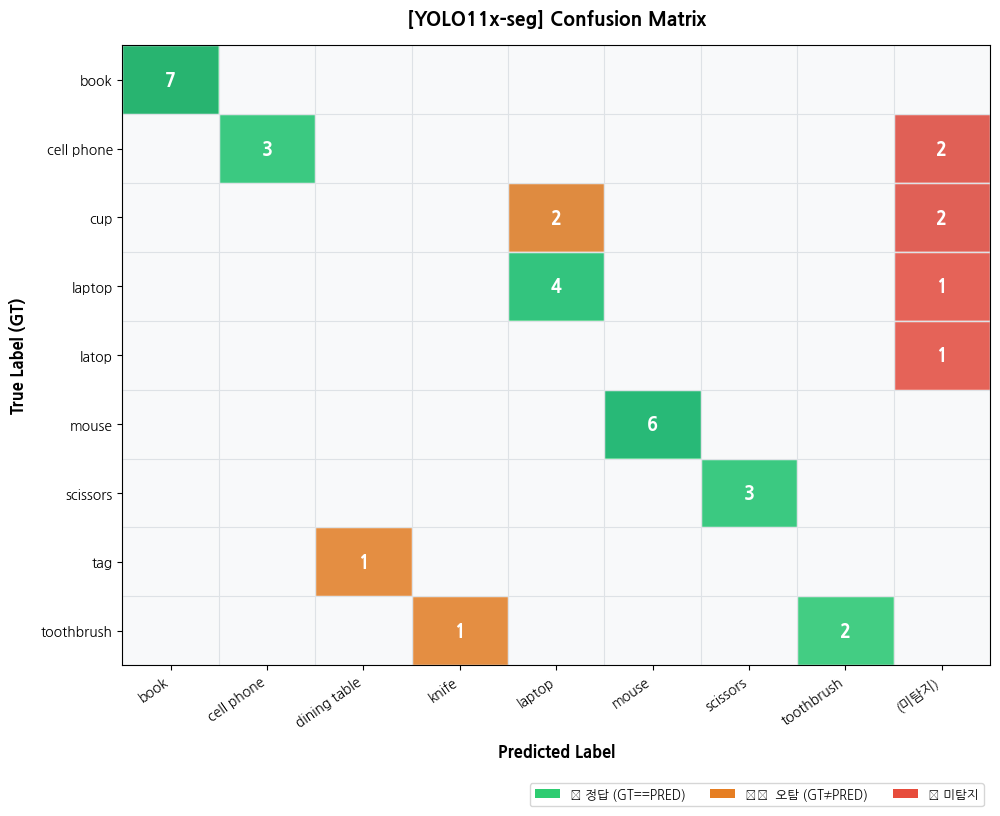

✅ 저장: results/output_confusion_YOLO11x-seg.png
  정답(GT==PRED) : 25/35  (71.4%)
  오탐(라벨 틀림): 4/35  (11.4%)
  미탐지         : 6/35  (17.1%)

  🤖 YOLO11n-seg


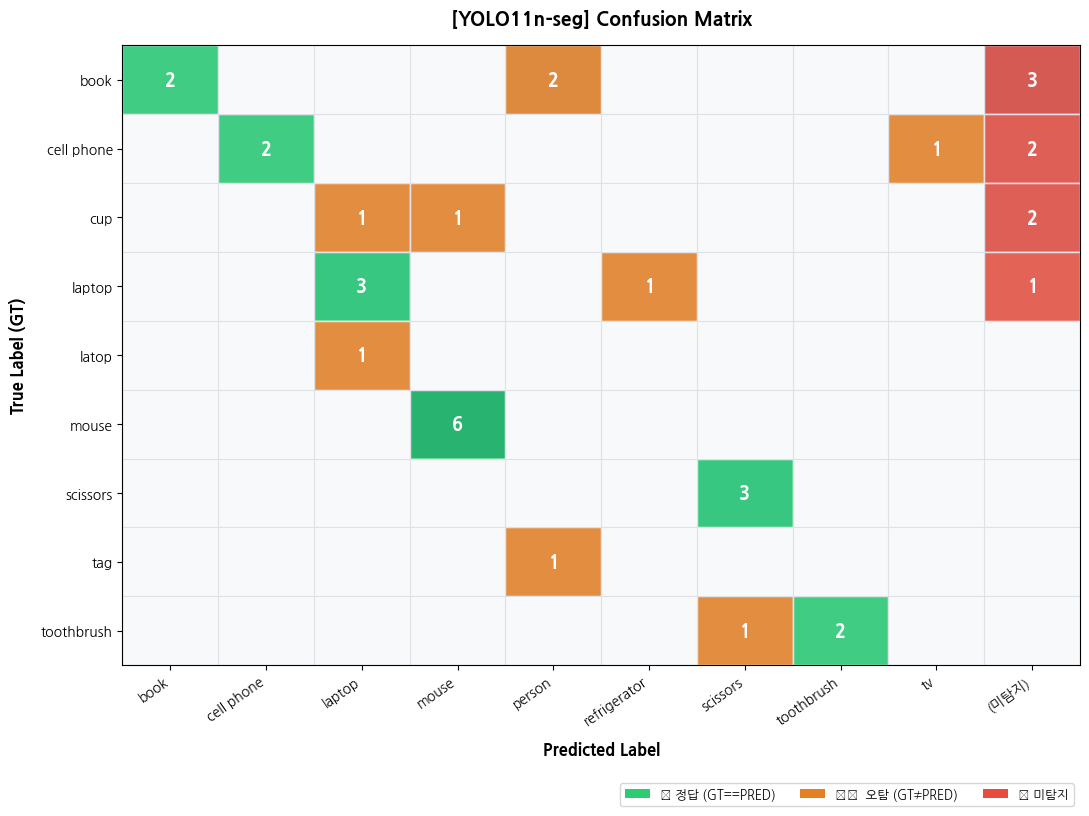

✅ 저장: results/output_confusion_YOLO11n-seg.png
  정답(GT==PRED) : 18/35  (51.4%)
  오탐(라벨 틀림): 9/35  (25.7%)
  미탐지         : 8/35  (22.9%)

✅ Confusion Matrix 완료


In [6]:
def draw_confusion_matrix(model_name, img_results):
    """Confusion Matrix 시각화 및 Precision/Recall 계산"""
    pair_counts  = defaultdict(int)
    gt_label_set = set()
    pred_label_set = set()

    for img_r in img_results:
        for r in img_r['eval_results']:
            gt   = r['gt_label']
            pred = r['pred_label'] if r['pred_label'] else '(미탐지)'
            pair_counts[(gt, pred)] += 1
            gt_label_set.add(gt)
            pred_label_set.add(pred)

    true_labels = sorted(gt_label_set)
    pred_labels = sorted(pred_label_set - {'(미탐지)'}) + \
                  (['(미탐지)'] if '(미탐지)' in pred_label_set else [])

    matrix = np.zeros((len(true_labels), len(pred_labels)), dtype=int)
    for (gt, pred), cnt in pair_counts.items():
        matrix[true_labels.index(gt), pred_labels.index(pred)] += cnt

    # Precision / Recall 계산
    cm_precision, cm_recall = {}, {}
    for label in true_labels:
        r_idx   = true_labels.index(label)
        tp      = matrix[r_idx, pred_labels.index(label)] if label in pred_labels else 0
        row_sum = matrix[r_idx].sum()
        col_sum = matrix[:, pred_labels.index(label)].sum() if label in pred_labels else 0
        cm_recall[label]    = float(tp / row_sum) if row_sum > 0 else 0.0
        cm_precision[label] = float(tp / col_sum) if col_sum > 0 else 0.0

    macro_p  = float(np.mean(list(cm_precision.values())))
    macro_r  = float(np.mean(list(cm_recall.values())))
    macro_f1 = (2 * macro_p * macro_r / (macro_p + macro_r)
                if (macro_p + macro_r) > 0 else 0.0)

    # 시각화
    fig_h = max(5, len(true_labels) * 0.7 + 2)
    fig_w = max(7, len(pred_labels) * 0.9 + 2)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.imshow(matrix, cmap='Blues', aspect='auto', vmin=0)

    COLOR_MAP = {
        'miss'   : '#e74c3c',
        'correct': '#2ecc71',
        'wrong'  : '#e67e22',
    }

    for r in range(len(true_labels)):
        for c in range(len(pred_labels)):
            val = matrix[r, c]
            if val == 0:
                ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1,
                             facecolor='#f8f9fa', edgecolor='#dee2e6', linewidth=0.5))
                continue
            pred_l = pred_labels[c]
            if pred_l == '(미탐지)':
                color = COLOR_MAP['miss']
            elif true_labels[r] == pred_l:
                color = COLOR_MAP['correct']
            else:
                color = COLOR_MAP['wrong']
            ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1,
                         facecolor=color, edgecolor='white', linewidth=1.0, alpha=0.85))
            ax.text(c, r, str(val), ha='center', va='center',
                    fontsize=13, fontweight='bold', color='white')

    ax.set_xticks(range(len(pred_labels)))
    ax.set_yticks(range(len(true_labels)))
    ax.set_xticklabels(pred_labels, rotation=35, ha='right', fontsize=10)
    ax.set_yticklabels(true_labels, fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold', labelpad=10)
    ax.set_ylabel('True Label (GT)', fontsize=12, fontweight='bold', labelpad=10)
    ax.set_title(f'[{model_name}] Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(np.arange(-0.5, len(pred_labels), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(true_labels), 1), minor=True)
    ax.grid(which='minor', color='#dee2e6', linewidth=0.8)
    ax.tick_params(which='minor', length=0)
    ax.legend(handles=[
        mpatches.Patch(facecolor=COLOR_MAP['correct'], label='✅ 정답 (GT==PRED)'),
        mpatches.Patch(facecolor=COLOR_MAP['wrong'],   label='⚠️  오탐 (GT≠PRED)'),
        mpatches.Patch(facecolor=COLOR_MAP['miss'],    label='❌ 미탐지'),
    ], loc='upper right', bbox_to_anchor=(1.0, -0.18), fontsize=9, ncol=3)
    plt.tight_layout()

    fname = f'output_confusion_{model_name.replace(" ", "_")}.png'
    plt.savefig(OUT / fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ 저장: {OUT}/{fname}')

    # 요약 수치 출력
    total   = sum(pair_counts.values())
    correct = sum(cnt for (gt, pred), cnt in pair_counts.items() if gt == pred)
    missed  = sum(cnt for (gt, pred), cnt in pair_counts.items() if pred == '(미탐지)')
    wrong   = total - correct - missed
    print(f'  정답(GT==PRED) : {correct}/{total}  ({correct/total:.1%})')
    print(f'  오탐(라벨 틀림): {wrong}/{total}  ({wrong/total:.1%})')
    print(f'  미탐지         : {missed}/{total}  ({missed/total:.1%})')

    return true_labels, cm_precision, cm_recall, macro_p, macro_r, macro_f1


# ── 모델별 실행
cm_store = {}

for model_name, img_results in ALL_RESULTS.items():
    print(f"\n{'='*55}")
    print(f'  🤖 {model_name}')
    print(f"{'='*55}")
    true_labels, cm_precision, cm_recall, macro_p, macro_r, macro_f1 = \
        draw_confusion_matrix(model_name, img_results)
    cm_store[model_name] = {
        'true_labels' : true_labels,
        'cm_precision': cm_precision,
        'cm_recall'   : cm_recall,
        'macro_p'     : macro_p,
        'macro_r'     : macro_r,
        'macro_f1'    : macro_f1,
    }

print('\n✅ Confusion Matrix 완료')


---
## 시각화 — Precision / Recall / F1 막대 그래프



  🤖 YOLO11x-seg


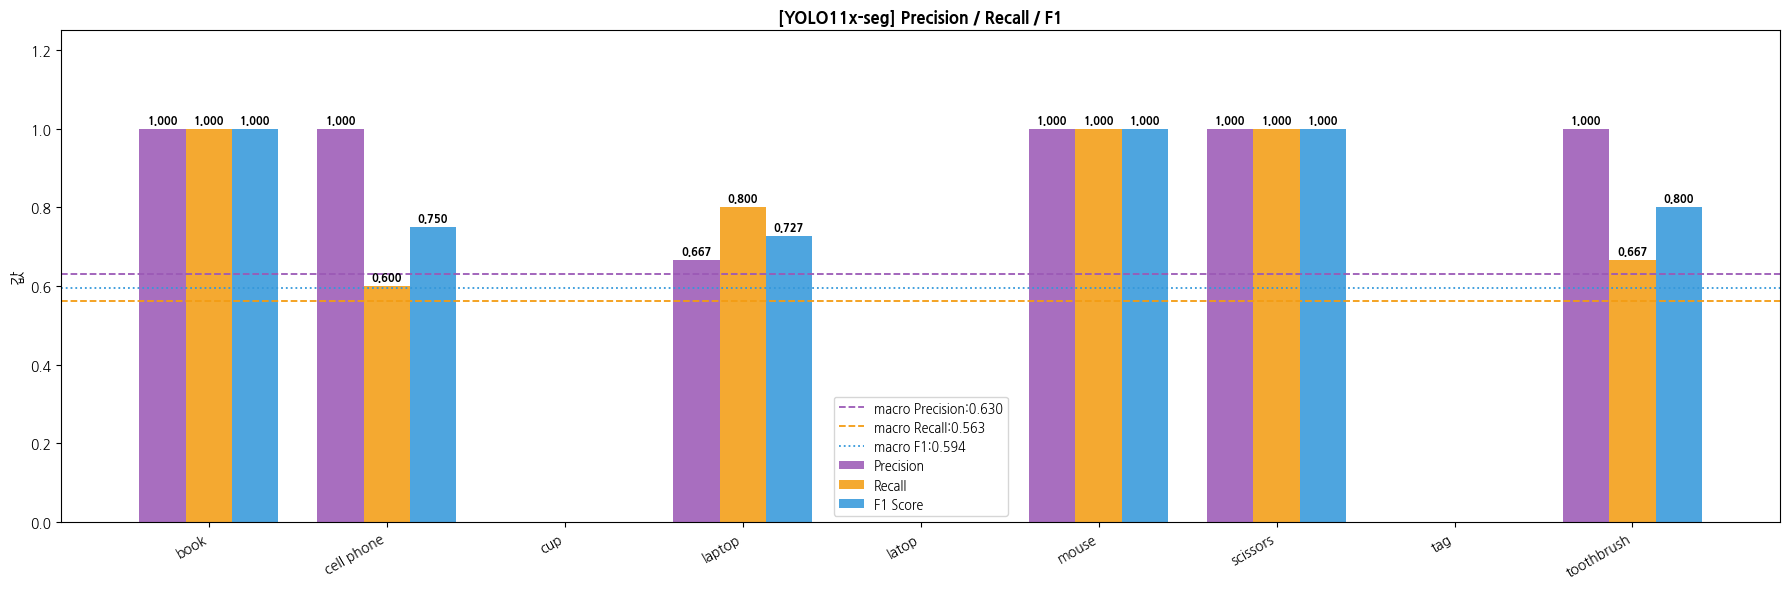

✅ 저장: results/output_pr_YOLO11x-seg.png

  🤖 YOLO11n-seg


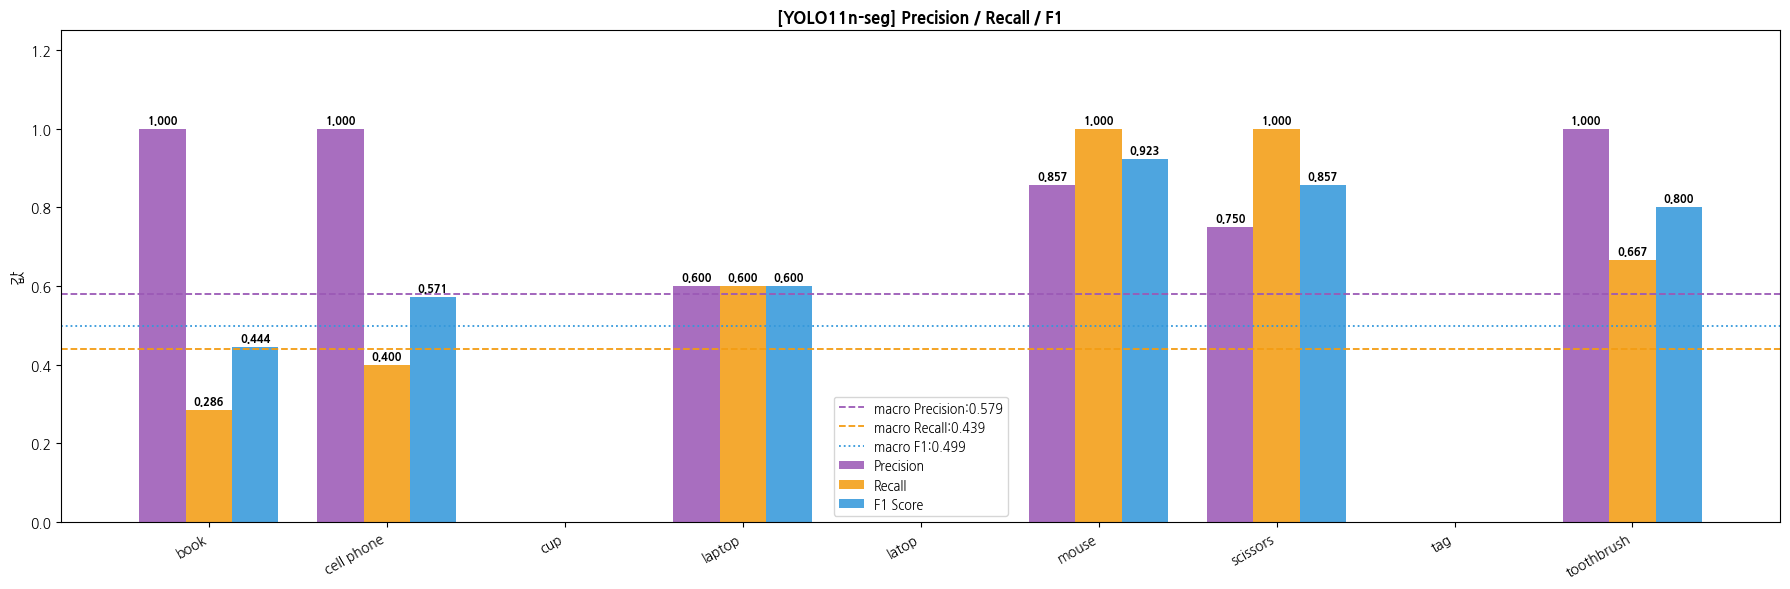

✅ 저장: results/output_pr_YOLO11n-seg.png

✅ PR 막대그래프 완료


In [7]:
def draw_pr_bar(model_name, store):
    labels    = store['true_labels']
    prec_vals = [store['cm_precision'][l] for l in labels]
    rec_vals  = [store['cm_recall'][l]    for l in labels]
    f1_vals   = [2*p*r/(p+r) if (p+r) > 0 else 0.0
                 for p, r in zip(prec_vals, rec_vals)]
    macro_p, macro_r, macro_f1 = store['macro_p'], store['macro_r'], store['macro_f1']

    x, w = np.arange(len(labels)), 0.26
    fig, ax = plt.subplots(figsize=(max(10, len(labels) * 2.0), 6))

    bars = [
        ax.bar(x - w, prec_vals, w, label='Precision', color='#9b59b6', alpha=0.87),
        ax.bar(x,     rec_vals,  w, label='Recall',    color='#f39c12', alpha=0.87),
        ax.bar(x + w, f1_vals,   w, label='F1 Score',  color='#3498db', alpha=0.87),
    ]
    for bar_group in bars:
        for b in bar_group:
            h = b.get_height()
            if h > 0.01:
                ax.text(b.get_x() + b.get_width() / 2, h + 0.01, f'{h:.3f}',
                        ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.axhline(macro_p,  color='#9b59b6', linestyle='--', linewidth=1.3,
               label=f'macro Precision:{macro_p:.3f}')
    ax.axhline(macro_r,  color='#f39c12', linestyle='--', linewidth=1.3,
               label=f'macro Recall:{macro_r:.3f}')
    ax.axhline(macro_f1, color='#3498db', linestyle=':',  linewidth=1.3,
               label=f'macro F1:{macro_f1:.3f}')

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=10)
    ax.set_ylim(0, 1.25)
    ax.set_ylabel('값', fontsize=11)
    ax.legend(fontsize=9)
    ax.set_title(f'[{model_name}] Precision / Recall / F1',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()

    fname = f'output_pr_{model_name.replace(" ", "_")}.png'
    plt.savefig(OUT / fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ 저장: {OUT}/{fname}')


for model_name, store in cm_store.items():
    print(f"\n{'='*55}")
    print(f'  🤖 {model_name}')
    print(f"{'='*55}")
    draw_pr_bar(model_name, store)

print('\n✅ PR 막대그래프 완료')


---
## 시각화 — Precision / Recall / F1 Heatmap



  🤖 YOLO11x-seg


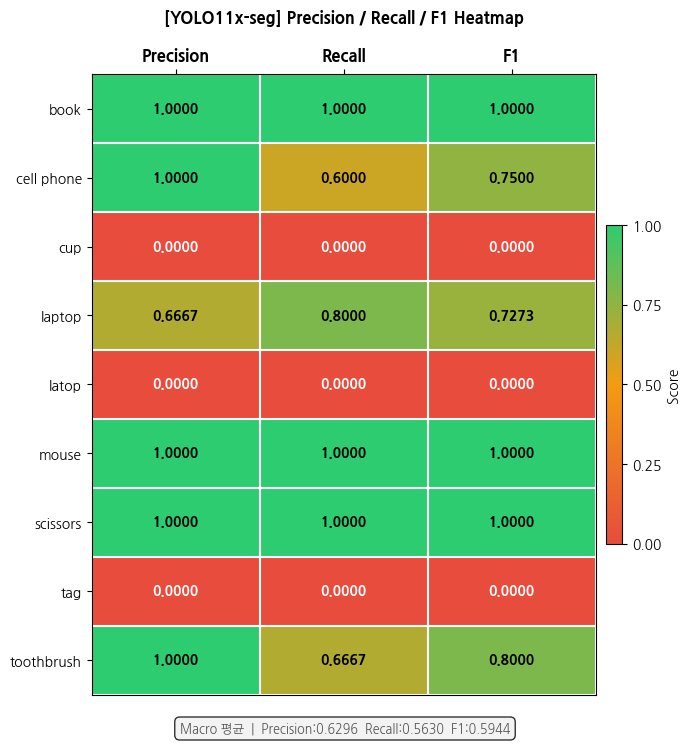

✅ 저장: results/output_heatmap_YOLO11x-seg.png

  🤖 YOLO11n-seg


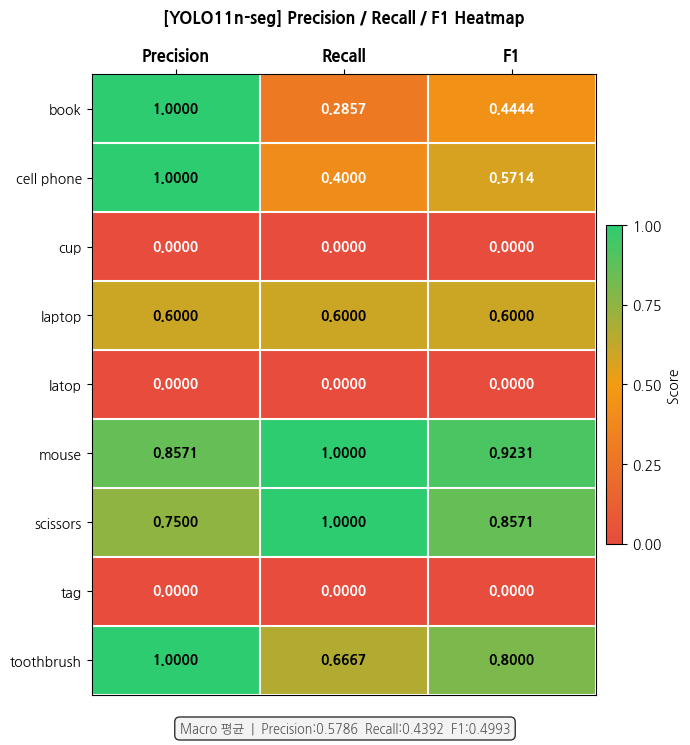

✅ 저장: results/output_heatmap_YOLO11n-seg.png

✅ Heatmap 완료


In [8]:
def draw_pr_heatmap(model_name, store):
    true_labels = store['true_labels']
    prec_h = [store['cm_precision'][l] for l in true_labels]
    rec_h  = [store['cm_recall'][l]    for l in true_labels]
    f1_h   = [2*p*r/(p+r) if (p+r) > 0 else 0.0 for p, r in zip(prec_h, rec_h)]
    data   = np.array([prec_h, rec_h, f1_h]).T  # shape (n_labels, 3)

    col_labels     = ['Precision', 'Recall', 'F1']
    n_labels, n_cols = len(true_labels), 3
    cmap = mcolors.LinearSegmentedColormap.from_list('rg', ['#e74c3c', '#f39c12', '#2ecc71'])

    fig, ax = plt.subplots(figsize=(7, max(4, n_labels * 0.55 + 2.5)))
    im = ax.imshow(data, cmap=cmap, aspect='auto', vmin=0, vmax=1)

    for r in range(n_labels):
        for c in range(n_cols):
            val = data[r, c]
            ax.text(c, r, f'{val:.4f}', ha='center', va='center',
                    fontsize=10, fontweight='bold',
                    color='white' if val < 0.6 else 'black')

    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(col_labels, fontsize=12, fontweight='bold')
    ax.set_yticks(range(n_labels))
    ax.set_yticklabels(true_labels, fontsize=10)
    ax.xaxis.set_ticks_position('top')
    ax.xaxis.set_label_position('top')
    ax.set_xticks(np.arange(-0.5, n_cols, 1),    minor=True)
    ax.set_yticks(np.arange(-0.5, n_labels, 1),  minor=True)
    ax.grid(which='minor', color='white', linewidth=1.5)
    ax.tick_params(which='minor', length=0)

    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label('Score', fontsize=10)
    cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])

    macro_p, macro_r, macro_f1 = store['macro_p'], store['macro_r'], store['macro_f1']
    macro_str = f'Precision:{macro_p:.4f}  Recall:{macro_r:.4f}  F1:{macro_f1:.4f}'
    ax.set_title(f'[{model_name}] Precision / Recall / F1 Heatmap',
                 fontsize=12, fontweight='bold', pad=18)
    fig.text(0.5, 0.01, f'Macro 평균  |  {macro_str}',
             ha='center', fontsize=9, color='#555555',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#f0f0f0', alpha=0.8))
    plt.tight_layout(rect=[0, 0.04, 1, 1])

    fname = f'output_heatmap_{model_name.replace(" ", "_")}.png'
    plt.savefig(OUT / fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ 저장: {OUT}/{fname}')


for model_name, store in cm_store.items():
    print(f"\n{'='*55}")
    print(f'  🤖 {model_name}')
    print(f"{'='*55}")
    draw_pr_heatmap(model_name, store)

print('\n✅ Heatmap 완료')


---
## OUTPUT — 모델별 성능 결과


In [9]:
# ── 전체 성능 요약
summary = {}

for model_name, img_results in ALL_RESULTS.items():
    all_rs  = [r for ir in img_results for r in ir['eval_results']]
    correct = sum(1 for r in all_rs if r['gt_label'] == r['pred_label'])
    total   = len(all_rs)
    summary[model_name] = {
        'correct'  : correct,
        'total'    : total,
        'label_acc': correct / total if total else 0.0,
        'avg_score': float(np.mean([r['score'] for r in all_rs])) if all_rs else 0.0,
        'avg_iou'  : float(np.mean([r['iou']   for r in all_rs])) if all_rs else 0.0,
    }

ranked = sorted(summary.items(),
                key=lambda x: (x[1]['label_acc'], x[1]['avg_score']),
                reverse=True)

W_COL = 72
print('\n' + '=' * W_COL)
print(f"  {'모델명':22} {'정답률':>12} {'정답/전체':>12} {'avg score':>12} {'avg IoU':>10}")
print('=' * W_COL)
for rank, (name, s) in enumerate(ranked):
    crown = ' 👑' if rank == 0 else f'  {rank+1} '
    print(f" {crown} {name:20} {s['label_acc']:>12.1%} "
          f"   {s['correct']:>4}/{s['total']:<4}   "
          f"{s['avg_score']:>12.4f} {s['avg_iou']:>10.4f}")
print('=' * W_COL)

# ── label별 정답률 (모델별)
for model_name, img_results in ALL_RESULTS.items():
    all_rs   = [r for ir in img_results for r in ir['eval_results']]
    by_label = defaultdict(list)
    for r in all_rs:
        by_label[r['gt_label']].append(r)

    print(f'\n  [{model_name}] label별 정답률')
    print(f"  {'label':25} {'정답률':>8} {'정답/전체':>10} {'avg score':>12}")
    print('  ' + '-' * 57)
    for label in sorted(by_label):
        rs  = by_label[label]
        cor = sum(1 for r in rs if r['gt_label'] == r['pred_label'])
        acc = cor / len(rs)
        sc  = float(np.mean([r['score'] for r in rs]))
        bar = '█' * int(acc * 10) + '░' * (10 - int(acc * 10))
        print(f"  {label:25} {acc:>8.1%}   {cor:>3}/{len(rs):<3}  {bar}  {sc:.4f}")

print('\n✅ 성능 요약 완료')



  모델명                             정답률        정답/전체    avg score    avg IoU
  👑 YOLO11x-seg                 71.4%      25/35           0.4192     0.6239
   2  YOLO11n-seg                 51.4%      18/35           0.2608     0.5294

  [YOLO11x-seg] label별 정답률
  label                          정답률      정답/전체    avg score
  ---------------------------------------------------------
  book                        100.0%     7/7    ██████████  0.4260
  cell phone                   60.0%     3/5    ██████░░░░  0.2893
  cup                           0.0%     0/4    ░░░░░░░░░░  0.0005
  laptop                       80.0%     4/5    ████████░░  0.5286
  latop                         0.0%     0/1    ░░░░░░░░░░  0.0000
  mouse                       100.0%     6/6    ██████████  0.6737
  scissors                    100.0%     3/3    ██████████  0.8433
  tag                           0.0%     0/1    ░░░░░░░░░░  0.0103
  toothbrush                   66.7%     2/3    ██████░░░░  0.3384

  [YOLO11n-seg]

---
## 시각화 — Label별 평균 IoU / Precision / Recall (전체 모델 통합)


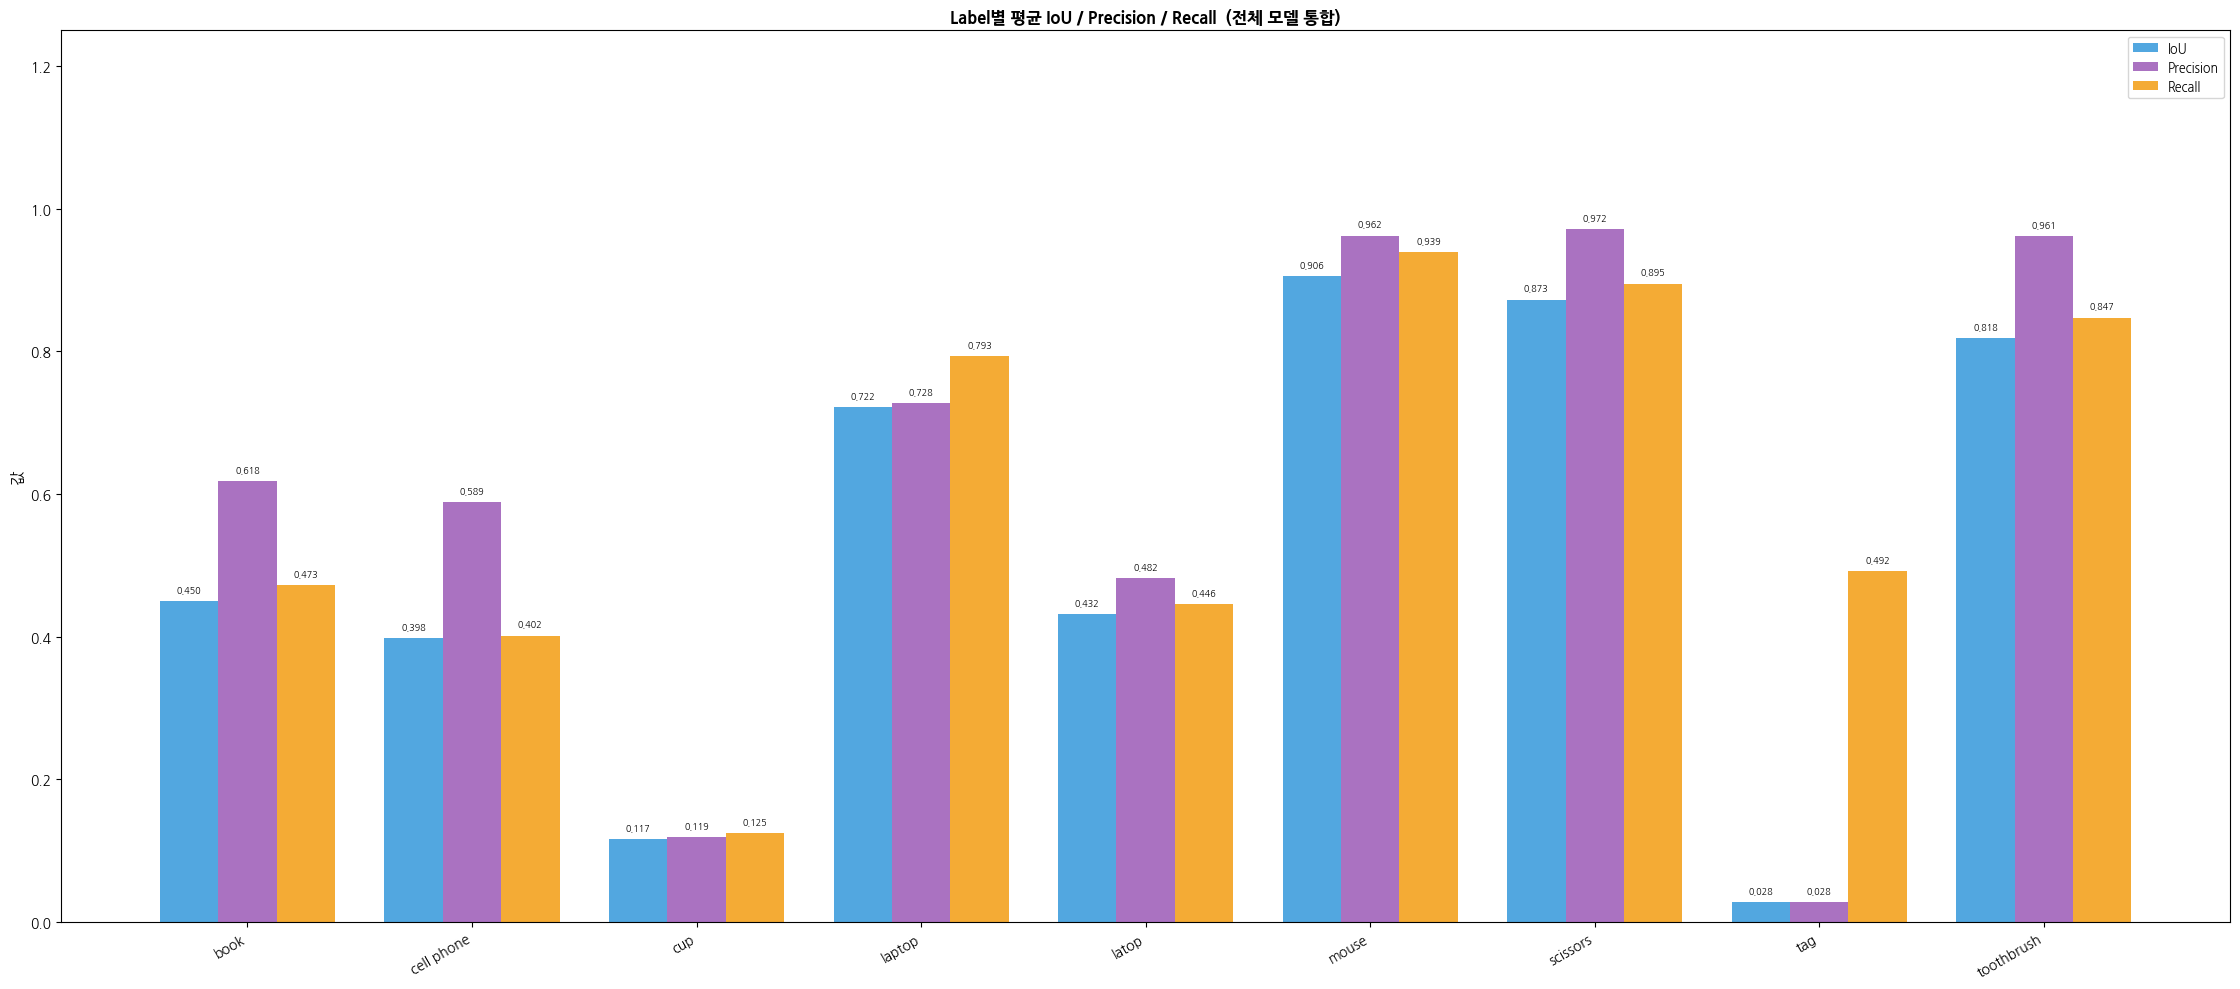

✅ 저장: results/output_label_score.png


In [10]:
label_stats = defaultdict(list)
for img_results in ALL_RESULTS.values():
    for img_r in img_results:
        for r in img_r['eval_results']:
            label_stats[r['gt_label']].append(r)

lnames = sorted(label_stats.keys())
l_iou  = [float(np.mean([r['iou']       for r in label_stats[l]])) for l in lnames]
l_prec = [float(np.mean([r['precision'] for r in label_stats[l]])) for l in lnames]
l_rec  = [float(np.mean([r['recall']    for r in label_stats[l]])) for l in lnames]

x, w = np.arange(len(lnames)), 0.26
fig, ax = plt.subplots(figsize=(max(20, len(lnames) * 2.5), 10))

bars = [
    ax.bar(x - w, l_iou,  w, label='IoU',       color='#3498db', alpha=0.85),
    ax.bar(x,     l_prec, w, label='Precision',  color='#9b59b6', alpha=0.85),
    ax.bar(x + w, l_rec,  w, label='Recall',     color='#f39c12', alpha=0.85),
]
for bar_group in bars:
    for b in bar_group:
        h = b.get_height()
        if h > 0.01:
            ax.text(b.get_x() + b.get_width() / 2, h + 0.01, f'{h:.3f}',
                    ha='center', va='bottom', fontsize=6.5)

ax.set_xticks(x)
ax.set_xticklabels(lnames, rotation=30, ha='right', fontsize=10)
ax.set_ylim(0, 1.25)
ax.set_ylabel('값', fontsize=11)
ax.legend(fontsize=9)
ax.set_title('Label별 평균 IoU / Precision / Recall  (전체 모델 통합)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'output_label_score.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ 저장: {OUT}/output_label_score.png')
